In [1]:
# === Standard Libraries ===
import os
import numpy as np
import pandas as pd
import scipy
from scipy.stats import median_abs_deviation
from tqdm import tqdm

# === PyTorch ===
import torch
from torch.utils.data import DataLoader
# from torchinfo import summary

# === Tangermeme
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise

# === Vinson Package ===
from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.model import _Exp
from vinson.io import SamplesDensityExtractor
from vinson.utils import one_hot_encode, get_iupac_char_from_alleles

# === Genome Tools ===
from genome_tools import GenomicInterval
from genome_tools.data.extractors import FastaExtractor, TabixExtractor

# === Plotting ===
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]



/home/mbrannon/.local/miniconda3/envs/tangermeme/lib/python3.8/site-packages/tangermeme/ersatz.py:475: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit(params, nopython=False, cache=True)


# Testing dataloader, model & loss function

In [2]:
from vinson.dataset import SeqEmbedDataset
from vinson.loss import poisson_loss
from vinson.model import BassetTrunkEmbed, CellEmbedding, EmbedModel

# Create model
embed = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk = BassetTrunkEmbed(embed.n_outputs)
model = EmbedModel(trunk, embed, regression=True)

/home/mbrannon/.local/miniconda3/envs/tangermeme/lib/python3.8/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


### Simulate the loss function

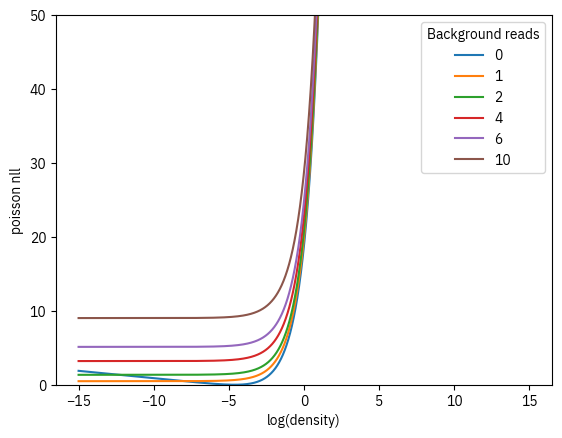

In [5]:
density = torch.tensor(0.01)
read_depth = 20e6
bg_reads = [0, 1, 2, 4, 6, 10]


input = torch.linspace(-15, 15, 10_000)

for i in bg_reads:
    pred_counts = (torch.exp(input) / 1e6 * read_depth) + i
    target_counts = density / 1e6 * read_depth

    loss = poisson_loss(pred_counts, target_counts, reduction="none")

    plt.plot(input, loss, label=f"{i}")

plt.ylim(0, 50)

plt.xlabel("log(density)")
plt.ylabel("poisson nll")


plt.legend(title="Background reads")

### Load in dataset and dataloader

In [272]:
samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL31/epoch_1/data_JUL31_pos.batch1.val.h5"
negative_samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL31/epoch_1/data_JUL31_neg.batch1.val.bed.gz"

embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
read_depth_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10/continious_annotation/total_cutcounts.tsv"
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"
sample_genotype_file = (
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v4/output/meta+sample_ids.tsv"
)
genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v4/output/all_variants_stats.bed.gz"

# General dataset params
dataset_kwargs = dict(
    negative_samples_rate=1,
    sample_genotype_file=sample_genotype_file,
    genotype_file=genotype_file,
    reverse_complement=False,
    jitter=0,
    noise=0,
    seed=0,
)

dataset = SeqEmbedDataset(
    samples_file,
    embeddings_file,
    read_depth_file,
    fasta_file,
    negative_samples_file=negative_samples_file,
    **dataset_kwargs,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True,
)

# Train model

To train model edit and run the following script: ```sbatch train.sh```

# Analyze, predict & interpret model

### Load in pre-trained variant model

In [3]:
pretrained_state_dict = torch.load(
    "/home/jvierstra/proj/vinson/models/data_AUG3_with_warmup_and_decay/checkpoints/epoch=5-step=2106188-val_loss=21.51.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

model.load_state_dict(pretrained_state_dict)

<All keys matched successfully>

### Predict variants (random batch)

In [274]:
batch = next(iter(dataloader))

X_seq, X_embed, indicator, density, bg, read_depth, sample_id, chrom, mid, weight = (
    batch["seq"],
    batch["embed"],
    batch["indicator"],
    batch["density"],
    batch["bg"],
    batch["read_depth"],
    batch["sample_id"],
    batch["chrom"],
    batch["mid"],
    batch["weight"],
)

In [275]:
X_seq.shape

torch.Size([128, 4, 1344])

In [276]:
X_embed.shape

torch.Size([128, 637])

#### Predicted vs. observed read counts

In [ ]:
y_ = model(X_seq, X_embed).squeeze().detach()

ps = 1e-6
pred_counts = (torch.exp(y_) / 1e6 * read_depth) + bg
pred_counts = pred_counts.detach()

target_counts = density / 1e6 * read_depth
target_counts = target_counts.detach()

bg_density = bg / read_depth * 1e6
pred_total_density = torch.exp(y_) + bg_density

loss = poisson_loss(pred_counts + ps, target_counts + ps, reduction="none")
loss *= weight

print(f"loss = {loss.mean()}")

In [ ]:
x = (target_counts + 1).log()
y = (pred_counts + 1).log()

plt.scatter(
    x,
    y,
    c=indicator,
)

plt.plot([0, 7], [0, 7], color="k", ls="--")

plt.xlabel("Observed read counts (log x+1)")
plt.ylabel("Predicted read counts (log x+1)")

pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted read counts")

plt.gcf().set_size_inches(4, 4)

In [ ]:
x = (density + 0.05).log2()
y = pred_total_density.log2()

plt.scatter(x, y, c=indicator)
plt.gcf().set_size_inches(4, 4)

plt.plot([-5, 2], [-5, 2], color="k", ls="--")

plt.xlabel("Observed density (log x)")
plt.ylabel("Predicted density (log x + bg)")


pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted density")

#### Predicted vs. observed peak densities

In [ ]:
pred_w_peak = pred_total_density.log2()[indicator.to(bool)]
pred_wo_peak = pred_total_density.log2()[~indicator.to(bool)]


obs_w_peak = (density + 0.01).log2()[indicator.to(bool)]
obs_wo_peak = (density + 0.01).log2()[~indicator.to(bool)]

y = [
    obs_w_peak,
    pred_w_peak,
    obs_wo_peak,
    pred_wo_peak,
]

b = plt.boxplot(y, showfliers=False)

plt.xticks(
    np.arange(len(y)) + 1,
    labels=[
        "Observed -- peak",
        "Predicted -- peak",
        "Observed -- no peak",
        "Predicted -- no peak",
    ],
    rotation=45,
    ha="right",
)

plt.ylabel("Peak density")

#### Prediction error by peak density

In [ ]:
lfc_abs = lfc.abs()

x = lfc_abs[density > 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Strong peaks (density > 0.5)")

x = lfc_abs[density < 0.1]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Weak peaks (density < 0.1)")

plt.xlabel("Prediction error\n|log( predicted/observed)|")
plt.ylabel("Fraction of examples")

plt.legend()

plt.xlim(0, 5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Model prediction error by peak density")

#### Predict Specific Region

In [283]:
y_.shape


torch.Size([4159, 1])

In [284]:
#umap

In [287]:
#compare to acutal densities
pattern = "/net/seq/data2/projects/ENCODE4Plus/hotspot3/human/dnase/peak_calls.v23/{x}/{x}.normalized_density.bw"
density_extr = SamplesDensityExtractor(embeddings_file, pattern)
dens = density_extr[interval.center]

# Make sure it's a DataFrame for merging
prediction_df = dens.rename("actual").reset_index()
prediction_df= prediction_df.rename(columns={"index": "ag_id"})
meta_df = meta_df.merge(prediction_df, on="ag_id", how="left")

KeyboardInterrupt: 

In [ ]:
# plot actual
plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(
    data=meta_df,
    x="TSNE1",
    y="TSNE2",
    hue="actual",
    palette="Reds",
    s=60,
    edgecolor="k",
    linewidth=0.2,
)

plt.title(f"t-SNE of Embeddings\nColored by Observed Density {interval}")

# Manual colorbar with consistent normalization
norm = mpl.colors.Normalize(
    vmin=meta_df["actual"].min(),
    vmax=meta_df["actual"].max()
)
sm = mpl.cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=scatter, fraction=0.03, pad=0.04)
cbar.set_label("Observed Density")

# Optional: custom ticks
cbar_ticks = np.linspace(
    meta_df["actual"].min(),
    meta_df["actual"].max(),
    num=10
)
cbar.set_ticks(cbar_ticks)

plt.tight_layout()
plt.show()

In [40]:
#plot correlation across all cells

### Contribution scores

In [45]:
# Store all SHAP results in a list
all_attrs = []

# Loop over all embeddings (assuming X_embed.shape[0] == 10)
for i in range(X_embed.shape[0]):
    _X = force_strict_ohe(X_seq_repeated[i:i+1].clone())  # (1, 1344, 4)
    Y_embed = X_embed[i:i+1].clone()                      # (1, embed_dim)

    # Run DeepLIFT/SHAP
    attrs = deep_lift_shap(
        model,
        _X,
        args=(Y_embed,),
        device="cpu",
        print_convergence_deltas=True,
        references=dinucleotide_shuffle,
        additional_nonlinear_ops={_Exp: _nonlinear}
    )
    all_attrs.append(attrs[0])  # shape: (1344, 4)

      # shape: (1344, 4)

tensor([7.1526e-07, 1.1921e-06, 0.0000e+00, 2.3842e-07, 0.0000e+00, 1.4305e-06,
        7.1526e-07, 2.3842e-07, 0.0000e+00, 9.5367e-07, 4.7684e-07, 4.7684e-07,
        4.7684e-07, 7.1526e-07, 2.3842e-07, 0.0000e+00, 0.0000e+00, 2.3842e-07,
        4.7684e-07, 9.5367e-07], grad_fn=<AbsBackward0>)
tensor([9.5367e-07, 2.3842e-07, 0.0000e+00, 2.3842e-07, 4.7684e-07, 0.0000e+00,
        2.3842e-07, 4.7684e-07, 2.3842e-07, 0.0000e+00, 4.7684e-07, 1.1921e-06,
        2.3842e-07, 4.7684e-07, 1.4305e-06, 4.7684e-07, 9.5367e-07, 0.0000e+00,
        2.3842e-07, 7.1526e-07], grad_fn=<AbsBackward0>)
tensor([4.7684e-07, 0.0000e+00, 2.3842e-07, 4.7684e-07, 4.7684e-07, 2.3842e-07,
        2.3842e-07, 1.4305e-06, 4.7684e-07, 2.3842e-07, 0.0000e+00, 1.4305e-06,
        0.0000e+00, 1.4305e-06, 1.4305e-06, 4.7684e-07, 9.5367e-07, 2.3842e-07,
        0.0000e+00, 1.6689e-06], grad_fn=<AbsBackward0>)
tensor([0.0000e+00, 0.0000e+00, 2.3842e-07, 4.7684e-07, 0.0000e+00, 4.7684e-07,
        1.1921e-06, 4.7684e-0

In [50]:
# if looking at one cell type
attrs_stack = torch.stack(all_attrs, dim=0)  # shape: (9, 4, 1344)

# Compute the mean across the 9 samples (axis 0)
mean_attrs = attrs_stack.mean(dim=0)  # shape: (4, 1344)

In [52]:
attrs_stack.shape

torch.Size([9, 4, 1344])

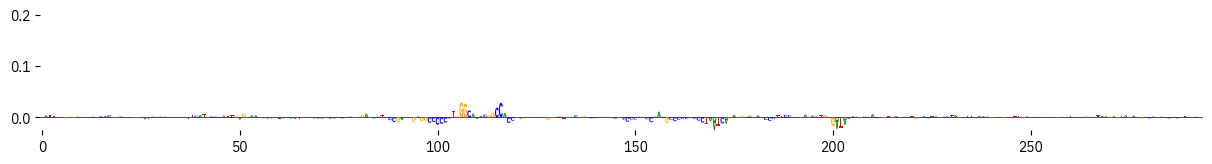

In [11]:
# Plot averaged SHAP scores
fig, ax = plt.subplots()
#use mean_attrs for cell type consensus 
#use attrs[0] for random dataset value
plot_logo(mean_attrs[:, 550:-500], ax=ax)  # Adjusted region
ax.set_ylim(top=0.2)
fig.set_size_inches(15, 1.5)
plt.show()

In [313]:
i = 34
torch.exp(y_[i]), density[i] - bg_density[i], density[i]

In [314]:
_X = force_strict_ohe(X_seq[i : i + 1].clone())

Y_embed = X_embed[i : i + 1].clone()

# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model,
    _X,
    args=(Y_embed,),
    model_kwargs=dict(exp=True),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

Y_embed_rand = torch.tensor(dataset.embeddings_df.iloc[:, 5].values[np.newaxis,:]).to(torch.float32)

attrs_rand = deep_lift_shap(
    model,
    _X,
    args=(Y_embed_rand,),
    model_kwargs=dict(exp=True),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

tensor([2.3842e-07, 2.3842e-07, 7.1526e-07, 4.7684e-07, 9.5367e-07, 7.1526e-07,
        1.4305e-06, 2.3842e-07, 4.7684e-07, 2.1458e-06, 7.1526e-07, 1.1921e-07,
        1.4305e-06, 1.1921e-07, 7.1526e-07, 9.5367e-07, 1.1921e-06, 9.5367e-07,
        7.1526e-07, 9.5367e-07], grad_fn=<AbsBackward0>)


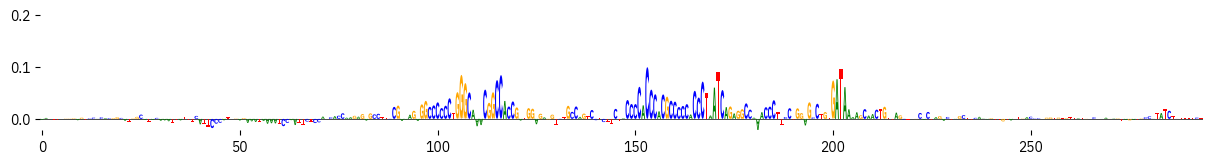

In [315]:
fig, ax = plt.subplots()
plot_logo(attrs[0][:, 550:-500], ax=ax)
ax.set_ylim(top=0.05)
fig.set_size_inches(15, 1.5)

In [ ]:
fig, ax = plt.subplots()
plot_logo(attrs_rand[0][:, 550:-500], ax=ax)
ax.set_ylim(top=0.05)
fig.set_size_inches(15, 1.5)

#### pairwise embedding

In [ ]:
fasta_extr = FastaExtractor('/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa')

# Define region
chrom = "chr2"
mid = (60495037 + 60495338) // 2  # 60495187
seqlen = 1344

# Get sequence from fasta
interval = GenomicInterval(chrom, mid, mid).widen(seqlen // 2)
dna_seq = fasta_extr[interval]  # This gives you the raw sequence

# checking for cell type names
rep_embed = pd.read_table('/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/representative_samples_by_annotation_stratified.tsv')
rep_embed['extended_annotation'].unique()


X_seq = one_hot_encode(dna_seq, dtype=np.float32)  # shape: (1344, 4)
X_seq = torch.tensor(X_seq).unsqueeze(0)  # shape: (1, 1344, 4)

embeddings_df = pd.read_csv("/home/jvierstra/proj/vinson/data/embeddings.tsv", sep="\t", index_col=0)
#X_embed = torch.tensor(embeddings_df.T.values, dtype=torch.float32)  # shape: (num_embeddings, embed_dim)

#if want only specific embeddings
ag_want = rep_embed[rep_embed['extended_annotation'] == 'Erythroid'].sample_id.values
filtered_embeddings = embeddings_df[ag_want].T  # shape: (len(ag_ids_to_keep), embedding_dim)
X_embed = torch.tensor(filtered_embeddings.values, dtype=torch.float32)

#get dataset with same number seq as embed
X_seq_repeated = X_seq.repeat(X_embed.shape[0], 1, 1)  # shape: (num_embeddings, 1344, 4)



y_ = model(X_seq_repeated, X_embed)
y = y_.squeeze().detach()

In [207]:
Y_all = apply_pairwise(
    predict, 
    model, 
    _X, #force_strict_ohe(X_seq), #_X, 
    args=(torch.as_tensor(dataset.embeddings_df.T.values),), device="cpu", verbose=True)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f4302fe6640>>
Traceback (most recent call last):
  File "/home/mbrannon/.local/miniconda3/envs/tangermeme/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
plt.hist(Y_all.squeeze().exp())

plt.xlabel("Predicted density")
plt.ylabel("Number of samples")

In [ ]:
from openTSNE import TSNE

tsne = TSNE(
    perplexity=20,
    metric="euclidean",
    n_jobs=1,
    random_state=42,
    verbose=True,
)

embedding_train = tsne.fit(X_embed.to_numpy())

In [ ]:
def zscore_normalization(series):
    return (series - series.mean()) / series.std()

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=zscore_normalization(Y_all.squeeze().exp()), vmin=0, vmax=3, cmap="Reds")

axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Predicted density")

ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.spines[['left', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

fig.suptitle("Predicted DHS activity across cell types")



In [138]:
sample_id[i]


'AG80507'

In [139]:
k = np.argsort(Y_all.squeeze())

In [140]:
dataset.embeddings_df.columns[k][-30:]

Index(['AG80790', 'AG79956', 'AG80746', 'AG80781', 'AG80804', 'AG80765',
       'AG80401', 'AG80782', 'AG80814', 'AG80402', 'AG80803', 'AG80773',
       'AG80423', 'AG80758', 'AG80760', 'AG80443', 'AG80761', 'AG80414',
       'AG80413', 'AG80694', 'AG80444', 'AG80422', 'AG80409', 'AG80407',
       'AG80410', 'AG80421', 'AG80416', 'AG80408', 'AG80415', 'AG80420'],
      dtype='object')

In [ ]:
interval = GenomicInterval("chr2", 60_495_037, 60_495_338)
mid = (interval.start + interval.end) // 2
interval = GenomicInterval(interval.chrom, mid, mid).widen(672)

In [209]:
X_BCL11A = intervals_to_one_hot(interval, seqlen=1344, fasta_extr=fasta_extr)

In [ ]:
Y_BCL11A = apply_pairwise(
    predict, 
    model, 
    torch.as_tensor(X_BCL11A), #force_strict_ohe(X_seq), #_X, 
    args=(torch.as_tensor(dataset.embeddings_df.T.values),), device="cpu", verbose=True)


In [213]:
pattern = "/net/seq/data2/projects/ENCODE4Plus/hotspot3/human/dnase/peak_calls.v23/{x}/{x}.normalized_density.bw"

density_extr = SamplesDensityExtractor(embeddings_file, pattern)

dens = density_extr[interval.center]

KeyboardInterrupt: 

In [ ]:
def z_mads(x):
    median = np.median(x)
    mads = median_abs_deviation(x, scale="normal")
    return (x-median)/mads

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=Y_BCL11A.squeeze().exp(), vmin=0, vmax=1, cmap="Reds")
#sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=zscore_normalization(dens), vmin=0, vmax=3, cmap="Reds")

axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Predicted density")

# ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.spines[['left', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

fig.suptitle("Predicted DHS activity across cell types")



In [ ]:
plt.hist(z_mads(dens))

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

#sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=zscore_normalization(Y_BCL11A.squeeze().exp()), vmin=1, vmax=3, cmap="Reds")
sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=dens, vmin=0, vmax=3, cmap="Reds")

axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Predicted density")

# ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.spines[['left', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

fig.suptitle("Predicted DHS activity across cell types")


In [ ]:
plt.hist(Y_BCL11A.squeeze().exp())

In [ ]:
k = np.argsort(Y_BCL11A.squeeze())
dataset.embeddings_df.columns[k][-30:]

In [ ]:
E = torch.as_tensor(dataset.embeddings_df["AG95435"].values).to(torch.float32)
E = E.unsqueeze(0)

attrs = deep_lift_shap(
    model,
    torch.as_tensor(X_BCL11A),
    args=(E,),
    model_kwargs=dict(exp=True),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)


In [ ]:
fig, ax = plt.subplots()
plot_logo(torch.flip(attrs[0][:, 625:-550], [0, 1]), ax=ax)
ax.set_ylim(top=0.025)
fig.set_size_inches(15, 1.5)

#### look at predicted data

In [ ]:
#head /home/mbrannon/tmp/AUG3_with_warmup_and_decay_prediction.tsv

#### Predict one region across all embeddings

In [76]:
interval = GenomicInterval("chr2", 60_495_037, 60_495_338)
mid = (interval.start + interval.end) // 2
interval = GenomicInterval(interval.chrom, mid, mid).widen(672)

In [78]:
from genome_tools import GenomicInterval
from vinson.utils import intervals_to_one_hot
X_BCL11A = intervals_to_one_hot(interval, seqlen=1344, fasta_extr=fasta_extr)

In [79]:
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise


In [81]:
Y_BCL11A = apply_pairwise(
    predict, 
    model, 
    torch.as_tensor(X_BCL11A, dtype=torch.float32), 
    args=(torch.as_tensor(dataset.embeddings_df.T.values, dtype=torch.float32),),
    device="cpu", 
    verbose=True
)


4159it [00:25, 165.82it/s]


In [83]:
from openTSNE import TSNE

tsne = TSNE(
    perplexity=20,
    metric="euclidean",
    n_jobs=1,
    random_state=42,
    verbose=True,
)

embedding_train = tsne.fit(dataset.embeddings_df.T.to_numpy())

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, perplexity=20, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 60 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 3.89 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.35 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.66 seconds
===> Running optimization with exaggeration=12.00, lr=346.58 for 250 iterations...
Iteration   50, KL divergence 3.4591, 50 iterations in 6.8615 sec
Iteration  100, KL divergence 3.3978, 50 iterations in 6.0360 sec
Iteration  150, KL divergence 3.3735, 50 iterations in 6.0622 sec
Iteration  200, KL divergence 3.3629, 50 iterations in 6.0720 sec
Iteration  250, KL divergence 3.3576, 50 iterations in 6.0717 sec
   --> Time elapsed: 31.10 seconds
===> Running optimization with exaggerat

Text(0.5, 0.98, 'Predicted DHS activity across cell types')

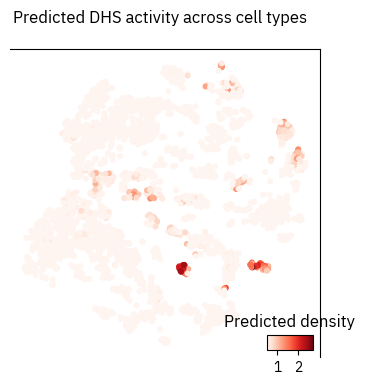

In [84]:
from matplotlib import colors

divnorm = colors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=5)

zo = Y_BCL11A.squeeze().exp() > 2

fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=Y_BCL11A.squeeze().exp(), cmap="Reds", vmin=0.5)

axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Predicted density")

# ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.spines[['left', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

fig.suptitle("Predicted DHS activity across cell types")



Text(0.5, 0.98, 'Observed DHS activity across cell types')

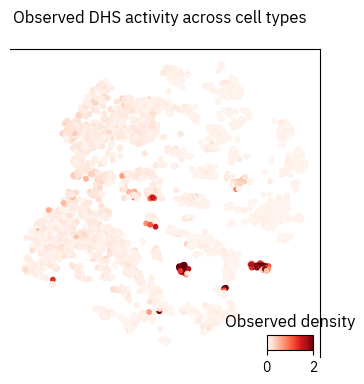

In [85]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

sc = ax.scatter(embedding_train[:,0], embedding_train[:,1], s=10, c=dens, vmin=0, vmax=2, cmap="Reds")

axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Observed density")

# ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.spines[['left', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

fig.suptitle("Observed DHS activity across cell types")


In [87]:
pred = Y_BCL11A.squeeze().exp()

In [132]:
read_counts_df = pd.read_csv(
    "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10/continious_annotation/total_cutcounts.tsv",
    sep="\t"
)

# Convert dens Series to DataFrame with proper column names
dens_df = dens.rename("obs_density").reset_index()
dens_df = dens_df.rename(columns={"index": "ag_id"})

# Prepare predicted density DataFrame
pred_df = pd.DataFrame({
    "ag_id": dens.index,
    "pred_density": Y_BCL11A.squeeze().exp().cpu().numpy()
})

# Prepare t-SNE coordinates DataFrame
tsne_df = pd.DataFrame({
    "ag_id": dens.index,
    "tsne1": embedding_train[:, 0],
    "tsne2": embedding_train[:, 1]
})

# Merge all DataFrames on 'ag_id' in a single chain
merge_df = (
    tsne_df
    .merge(pred_df, on="ag_id")
    .merge(read_counts_df, on="ag_id")
    .merge(dens_df, on="ag_id")
)


In [136]:
merge_df["pred_counts"] = (
    torch.exp(torch.tensor(merge_df["pred_density"].values)) / 1e6 
    * torch.tensor(merge_df["total_cutcounts"].values)
).numpy()

# Target counts (from observed density)
merge_df["target_counts"] = (
    torch.tensor(merge_df["obs_density"].values) / 1e6
    * torch.tensor(merge_df["total_cutcounts"].values)
).numpy()


In [225]:
merge_df[merge_df['ag_id']==ag_want]

,ag_id,tsne1,tsne2,pred_density,total_cutcounts,obs_density,pred_counts,target_counts
3524,AG95390,14.911806,-41.339274,2.2582,14633814,3.758419,139.98497,55.000004


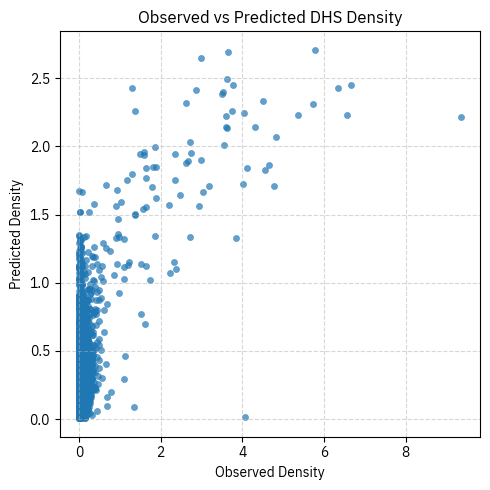

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merge_df,
    x="obs_density",
    y="pred_density",
    s=20,
    alpha=0.7,
    edgecolor=None
)

plt.xlabel("Observed Density")
plt.ylabel("Predicted Density")
plt.title("Observed vs Predicted DHS Density")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


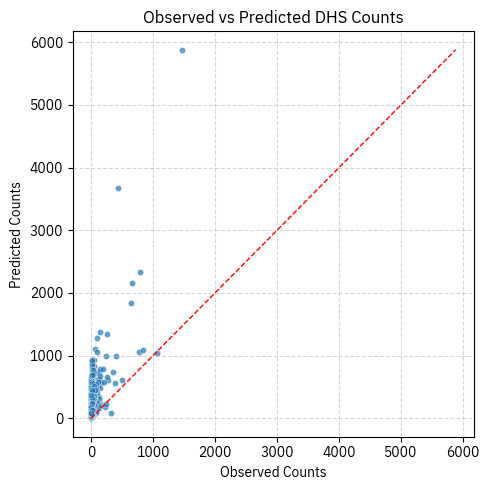

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merge_df,
    x="target_counts",
    y="pred_counts",
    s=20,
    alpha=0.7
)

# 1:1 reference line
max_val = max(merge_df["target_counts"].max(), merge_df["pred_counts"].max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=1)

plt.xlabel("Observed Counts")
plt.ylabel("Predicted Counts")
plt.title("Observed vs Predicted DHS Counts")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [143]:
from scipy.stats import pearsonr, spearmanr

# Counts correlations
pearson_counts_r, pearson_counts_p = pearsonr(merge_df["target_counts"], merge_df["pred_counts"])
spearman_counts_r, spearman_counts_p = spearmanr(merge_df["target_counts"], merge_df["pred_counts"])

# Density correlations
pearson_density_r, pearson_density_p = pearsonr(merge_df["obs_density"], merge_df["pred_density"])
spearman_density_r, spearman_density_p = spearmanr(merge_df["obs_density"], merge_df["pred_density"])

print("=== Counts Correlations ===")
print(f"Pearson r:  {pearson_counts_r:.4f} (p={pearson_counts_p:.2e})")
print(f"Spearman r: {spearman_counts_r:.4f} (p={spearman_counts_p:.2e})\n")

print("=== Density Correlations ===")
print(f"Pearson r:  {pearson_density_r:.4f} (p={pearson_density_p:.2e})")
print(f"Spearman r: {spearman_density_r:.4f} (p={spearman_density_p:.2e})")


=== Counts Correlations ===
Pearson r:  0.7019 (p=0.00e+00)
Spearman r: 0.6552 (p=0.00e+00)

=== Density Correlations ===
Pearson r:  0.6332 (p=0.00e+00)
Spearman r: 0.2583 (p=2.15e-64)


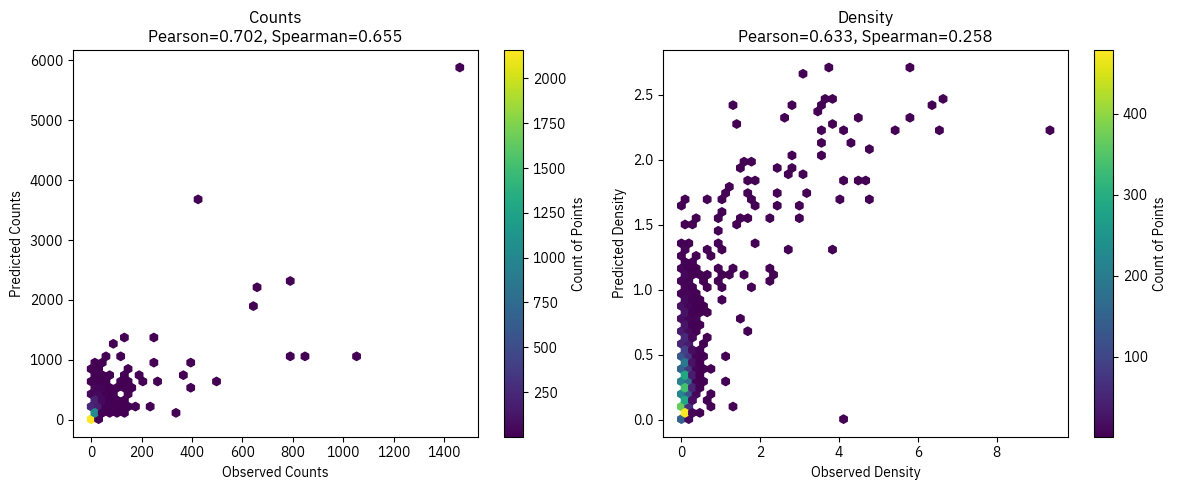

In [144]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Calculate correlations
pearson_counts_r, _ = pearsonr(merge_df["target_counts"], merge_df["pred_counts"])
spearman_counts_r, _ = spearmanr(merge_df["target_counts"], merge_df["pred_counts"])

pearson_density_r, _ = pearsonr(merge_df["obs_density"], merge_df["pred_density"])
spearman_density_r, _ = spearmanr(merge_df["obs_density"], merge_df["pred_density"])

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hexbin for counts
hb1 = axes[0].hexbin(
    merge_df["target_counts"],
    merge_df["pred_counts"],
    gridsize=50,
    cmap="viridis",
    mincnt=1
)
axes[0].set_xlabel("Observed Counts")
axes[0].set_ylabel("Predicted Counts")
axes[0].set_title(f"Counts\nPearson={pearson_counts_r:.3f}, Spearman={spearman_counts_r:.3f}")
cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label("Count of Points")

# Hexbin for density
hb2 = axes[1].hexbin(
    merge_df["obs_density"],
    merge_df["pred_density"],
    gridsize=50,
    cmap="viridis",
    mincnt=1
)
axes[1].set_xlabel("Observed Density")
axes[1].set_ylabel("Predicted Density")
axes[1].set_title(f"Density\nPearson={pearson_density_r:.3f}, Spearman={spearman_density_r:.3f}")
cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label("Count of Points")

plt.tight_layout()
plt.show()


#### predict all dhs in one sample

In [164]:
# checking for cell type names
rep_embed = pd.read_table('/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/representative_samples_by_annotation_stratified.tsv')
rep_embed['extended_annotation'].unique()


array(['Pluripotent/Pluripotent-derived', 'Cerebellum', 'CMP', 'Thyroid',
       'Cerebral cortex', 'Basal ganglia', 'Macrophage', 'Monocyte',
       'Limbic system', 'Intestine', 'Colon', 'Pancreas', 'Fibroblast',
       'Spinal cord', 'T-cell', 'B-cell', 'NK-cell', 'Fetal life support',
       'Hepatic', 'Heart', 'Muscle', 'Endothelium', 'Lung', 'Adrenal',
       'Epithelium', 'Ovary', 'Stomach', 'Kidney', 'Eye', 'Myoblast',
       'Stroma', 'Astrocyte', 'Erythroid', 'Dendritic'], dtype=object)

In [165]:
rep_embed[rep_embed['extended_annotation']=='T-cell']

,extended_annotation,sample_id
140,T-cell,AG72755
141,T-cell,AG93443
142,T-cell,AG93517
143,T-cell,AG80616
144,T-cell,AG92941
145,T-cell,AG95587
146,T-cell,AG93493
147,T-cell,AG92979
148,T-cell,AG80707
149,T-cell,AG96530


In [166]:
import pandas as pd
from genome_tools.data.extractors import FastaExtractor
from genome_tools import GenomicInterval
from vinson.utils import intervals_to_one_hot
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

# Path to files
bed_file = "/net/seq/data/dmz/www/data/encode4plus/encode-public/human/internal/by_aggregation/AG72755/AG72755.peaks.fdr0.001.bed.gz"

# Load fasta extractor
fasta_extr = FastaExtractor(fasta_file)

# Load BED file (at least first 3 columns)
bed_df = pd.read_csv(bed_file, sep="\t", usecols=[0, 1, 2])

# Make list of widened intervals
intervals = []
for _, row in bed_df.iterrows():
    mid = ((int(row["start"]) + int(row["end"])) // 2)
    interval = GenomicInterval(row["#chr"], mid, mid).widen(672)
    intervals.append(interval)

# Convert all intervals to one-hot
X_all = intervals_to_one_hot(intervals, seqlen=1344, fasta_extr=fasta_extr)



In [167]:
X_all.shape[0]

125420

In [168]:
rep_embed.loc[rep_embed['extended_annotation'] == 'T-cell', 'sample_id'].iloc[0]

'AG72755'

In [171]:
# Get the first erythroid embedding (just 1 row)
ag_want = rep_embed.loc[rep_embed['extended_annotation'] == 'T-cell', 'sample_id'].iloc[0]
embeddings_df = pd.read_csv("/home/jvierstra/proj/vinson/data/embeddings.tsv", sep="\t", index_col=0)
filtered_embedding = embeddings_df[ag_want].values  # shape: (num_rows,)

# Convert to tensor with shape (1, embedding_dim)
X_embed_single = torch.tensor(filtered_embedding, dtype=torch.float32).unsqueeze(0)


In [172]:
X_embed_single.shape

torch.Size([1, 637])

In [249]:

Y_celltype = apply_pairwise(
    predict, 
    model, 
    torch.as_tensor(X_all, dtype=torch.float32), 
    args=(torch.as_tensor(X_embed_single, dtype=torch.float32),),
    device="cpu", 
    verbose=True
)


125420it [11:44, 178.10it/s]


In [219]:
# Get the first erythroid embedding (just 1 row)
ag_want

'AG95390'

In [250]:
import pyBigWig as pbw
import numpy as np
from tqdm import tqdm

# Sample IDs (columns in your embeddings_df)
sample_ids = [ag_want]

# Open bigWig filehandles once
bw_filehandles = [
    pbw.open(f"/net/seq/data2/projects/ENCODE4Plus/hotspot3/human/dnase/peak_calls.v23/{sid}/{sid}.normalized_density.bw")
    for sid in sample_ids
]

densities = []

# Loop through each GenomicInterval
for interval in tqdm(intervals, total=len(intervals)):
    chrom = interval.chrom
    mid = (interval.start + interval.end) // 2

    vals = [
        fh.values(chrom, mid, mid + 1, numpy=True)[0]
        for fh in bw_filehandles
    ]

    vals = np.nan_to_num(vals, nan=0.0)  # Replace NaN with 0
    densities.append(vals)

# Convert to DataFrame
dens_df = pd.DataFrame(densities, columns=sample_ids)

# Close bigWig handles
for fh in bw_filehandles:
    fh.close()


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 125420/125420 [00:23<00:00, 5346.84it/s]


In [265]:
len(densities[0])

1

In [252]:
dens_df = pd.DataFrame(densities, columns=sample_ids)


In [253]:
dens_df

,AG72755
0,22.975693
1,0.707863
2,0.665220
3,8.072195
4,0.302761
...,...
125415,0.550086
125416,0.127927
125417,0.277175
125418,0.584200


In [254]:
Y_celltype.shape

torch.Size([125420, 1, 1])

In [256]:
df = pd.DataFrame({
    "obs_density": dens_df["AG72755"].values,
    "pred_density": torch.exp(Y_celltype.squeeze()).numpy()  # from log-space
})


In [257]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Calculate correlations
pearson_density_r, _ = pearsonr(df["obs_density"], df["pred_density"])
spearman_density_r, _ = spearmanr(df["obs_density"], df["pred_density"])

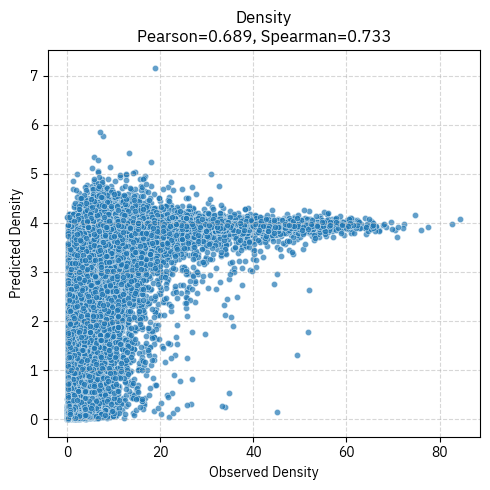

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=df,
    x="obs_density",
    y="pred_density",
    s=20,
    alpha=0.7
)

# 1:1 reference line
plt.xlabel("Observed Density")
plt.ylabel("Predicted Density")
plt.title(f"Density\nPearson={pearson_density_r:.3f}, Spearman={spearman_density_r:.3f}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


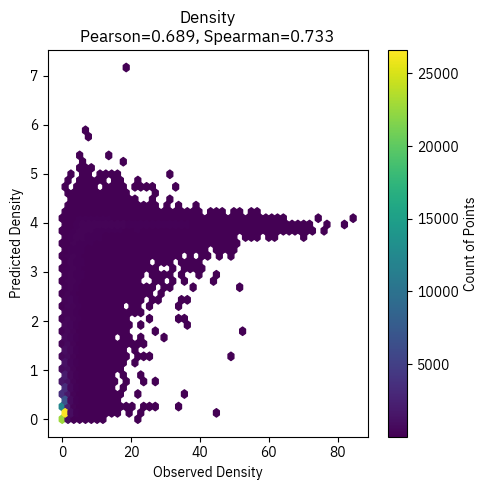

In [261]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
hb = plt.hexbin(
    df["obs_density"],
    df["pred_density"],
    gridsize=50,
    cmap="viridis",
    mincnt=1
)

# Labels and title
plt.xlabel("Observed Density")
plt.ylabel("Predicted Density")
plt.title(f"Density\nPearson={pearson_density_r:.3f}, Spearman={spearman_density_r:.3f}")

# Colorbar
cb = plt.colorbar(hb)
cb.set_label("Count of Points")

plt.tight_layout()
plt.show()


In [94]:
_X = torch.tensor(X_all, dtype=torch.float32)

Y_embed = X_embed_single

# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model,
    _X,
    args=(Y_embed,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)
'''
Y_embed_rand = torch.tensor(dataset.embeddings_df.iloc[:, 5].values[np.newaxis,:]).to(torch.float32)

attrs_rand = deep_lift_shap(
    model,
    _X,
    args=(Y_embed_rand,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)
'''

IndexError: index 1 is out of bounds for dimension 0 with size 1

In [141]:
X_seq_repeated.shape

torch.Size([9, 4, 1344])

In [142]:
#get only real scores
real_scores = (X_seq_repeated * attrs_stack).sum(axis=1)

In [143]:
real_scores.shape

torch.Size([9, 1344])

In [144]:
X=real_scores

In [145]:
X_attr = attrs_stack

In [146]:
from tangermeme.seqlet import tfmodisco_seqlets

seqlets = tfmodisco_seqlets(real_scores)
print(seqlets.shape)
seqlets.head()

(60, 4)


,example_idx,start,end,attribution
0,0,693,734,1.346110
1,0,727,768,0.936900
2,0,640,681,0.425037
3,0,672,713,0.411322
4,0,845,886,-0.198257


In [160]:
seqlet_annotations = seqlets.copy()
seqlet_annotations['example_idx'] = [motif_names[idx] for idx in motif_idxs]


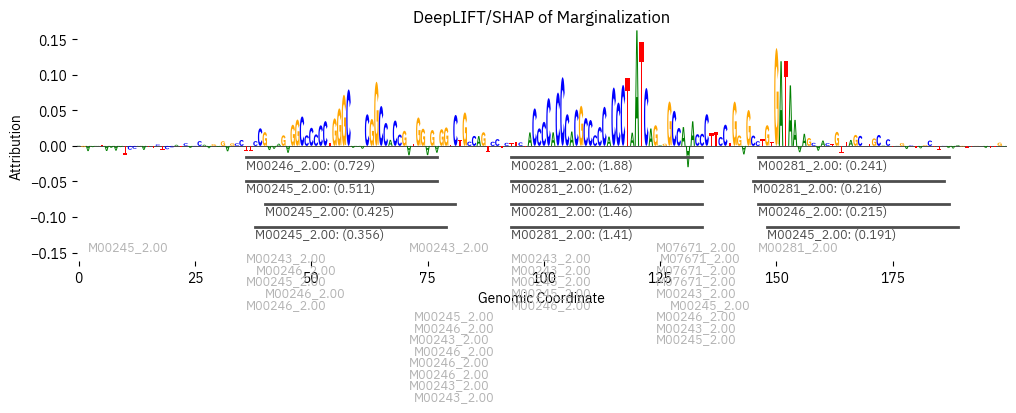

In [161]:
plt.figure(figsize=(12, 3))
ax = plt.subplot(111)
plot_logo(X_attr[3], ax=ax, start=600, end=800, annotations=seqlet_annotations, score_key="attribution")

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attribution")
plt.title("DeepLIFT/SHAP of Marginalization")
plt.show()

In [59]:
from tangermeme.seqlet import recursive_seqlets

seqlets = recursive_seqlets(real_scores, additional_flanks=0, threshold=0.01)


In [105]:
df_pos = seqlets[seqlets["attribution"] > 0].reset_index(drop=True)


In [148]:
from tangermeme.io import read_meme
from tangermeme.annotate import annotate_seqlets

meme_file = '/home/jvierstra/public_html/projects/motif-clustering-v2.1beta/all.dbs.meme'



In [149]:
motifs = read_meme(meme_file)
motif_idxs, motif_pvalues = annotate_seqlets(X_attr, seqlets, motifs)

In [150]:
from tangermeme.annotate import count_annotations

motifs = read_meme(meme_file)
motif_names = np.array(list(motifs.keys()))


y = count_annotations((seqlets['example_idx'], motif_idxs[:, 0]))


In [151]:
# If y is sparse and fits in memory as dense
motif_counts = y.to_dense().sum(dim=0)  # sum over rows (examples) → shape: [num_motifs]


In [152]:
motif_count_list = [(count.item(), idx) for idx, count in enumerate(motif_counts)]
# Optionally sort by count descending
motif_count_list.sort(reverse=True)


In [153]:
motifs = read_meme(meme_file)
index_to_name = [k for k, v in motifs.items()]
records = []
for count, idx in motif_count_list:
    name = index_to_name[idx]
    records.append((count, idx, name))


In [154]:


# records: list of tuples (count, idx, name)
motif_counts_df = pd.DataFrame(records, columns=["count", "motif_index", "motif_name"])

# Optional: sort by count descending
motif_counts_df  = motif_counts_df.sort_values(by="count", ascending=False).reset_index(drop=True)



In [155]:
motif_counts_df

,count,motif_index,motif_name
0,20,30,M00246_2.00
1,17,27,M00243_2.00
2,12,29,M00245_2.00
3,7,65,M00281_2.00
4,4,2996,M07671_2.00
...,...,...,...
2992,0,1997,M04997_2.00
2993,0,1996,M04996_2.00
2994,0,1995,M04995_2.00
2995,0,1994,M04994_2.00


In [156]:
import pandas as pd

# Load your DataFrame (already defined as `df`)
# Ensure motif_name is string
motif_counts_df["motif_name"] = motif_counts_df["motif_name"].astype(str)

# Load metadata
metadata = pd.read_csv(
    "/home/jvierstra/public_html/projects/motif-clustering-v2.1beta/metadata.tsv",
    sep="\t",
    dtype=str
)

# Merge on motif_name (df) and motif_id (metadata)
merged_df = motif_counts_df.merge(metadata, how="left", left_on="motif_name", right_on="motif_id")


In [157]:
# Merge on motif_name (df) and motif_id (metadata)
merged_df.head(20)

,count,motif_index,motif_name,motif_id,cluster,source_id,tf_name,family_name,motif_type,PMID
0,20,30,M00246_2.00,M00246_2.00,AC0441,WT1_R366L,WT1,C2H2 ZF,PBM,27013732
1,17,27,M00243_2.00,M00243_2.00,AC0441,WT1_F392L,WT1,C2H2 ZF,PBM,27013732
2,12,29,M00245_2.00,M00245_2.00,AC0441,WT1_R366C,WT1,C2H2 ZF,PBM,27013732
3,7,65,M00281_2.00,M00281_2.00,AC0441,PHOX2B_R141Q,PHOX2B,Homeodomain,PBM,27013732
4,4,2996,M07671_2.00,M07671_2.00,AC0478,ZNF93.RCADE.ReprocessedData,ZNF93,C2H2 ZF,ChIP-seq+ChIP-exo,29146583
5,0,998,M03591_2.00,M03591_2.00,AC0636,SREBF2_1,SREBF2,bHLH,SELEX,25779349
6,0,1007,M03925_2.00,M03925_2.00,AC0411,NR1I2_1,NR1I2,Nuclear receptor,SELEX,25779349
7,0,1006,M03924_2.00,M03924_2.00,AC0412,NR1I3_1,NR1I3,Nuclear receptor,SELEX,25779349
8,0,1005,M03923_2.00,M03923_2.00,AC0514,PGR_1,PGR,Nuclear receptor,SELEX,25779349
9,0,1004,M03886_2.00,M03886_2.00,AC0560,PAX3_2,PAX3,"Homeodomain,Paired box",SELEX,25779349


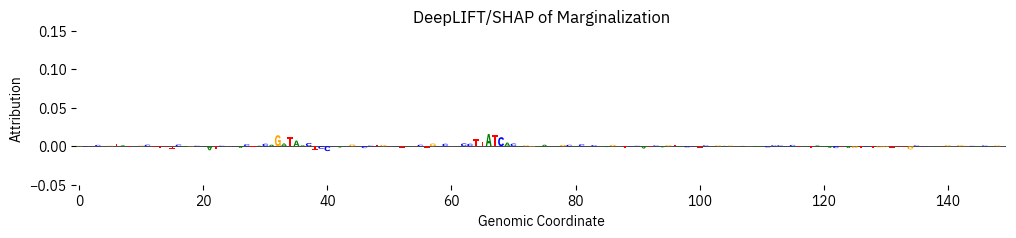

In [158]:
seqlet_annotations = seqlets.copy()
seqlet_annotations['example_idx'] = [motif_names[idx] for idx in motif_idxs]

plt.figure(figsize=(12, 2))
ax = plt.subplot(111)
plot_logo(X_attr[1], ax=ax, start=925, end=1075, annotations=seqlet_annotations, score_key='attribution', ylim=0.15)
plt.ylim(-0.05, 0.15)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attribution")
plt.title("DeepLIFT/SHAP of Marginalization")
plt.show()